In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
df  = pd.read_csv('../data/customer_churn.csv')

df.head(3)

,Names,Age,Total_Purchase,Account_Manager,Years,Num_Sites,Onboard_date,Location,Company,Churn
0,Cameron Williams,42.0,11066.80,0,7.22,8.0,2013-08-30 07:00:40,"10265 Elizabeth Mission Barkerburgh, AK 89518",Harvey LLC,1
1,Kevin Mueller,41.0,11916.22,0,6.50,11.0,2013-08-13 00:38:46,"6157 Frank Gardens Suite 019 Carloshaven, RI 1...",Wilson PLC,1
2,Eric Lozano,38.0,12884.75,0,6.67,12.0,2016-06-29 06:20:07,"1331 Keith Court Alyssahaven, DE 90114","Miller, Johnson and Wallace",1


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 900 entries, 0 to 899
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Names            900 non-null    str    
 1   Age              900 non-null    float64
 2   Total_Purchase   900 non-null    float64
 3   Account_Manager  900 non-null    int64  
 4   Years            900 non-null    float64
 5   Num_Sites        900 non-null    float64
 6   Onboard_date     900 non-null    str    
 7   Location         900 non-null    str    
 8   Company          900 non-null    str    
 9   Churn            900 non-null    int64  
dtypes: float64(4), int64(2), str(4)
memory usage: 70.4 KB


In [5]:
df.isnull().sum()

Names              0
Age                0
Total_Purchase     0
Account_Manager    0
Years              0
Num_Sites          0
Onboard_date       0
Location           0
Company            0
Churn              0
dtype: int64

In [6]:
df.isnull().sum().sum()

np.int64(0)

In [7]:
df[df.duplicated()]

,Names,Age,Total_Purchase,Account_Manager,Years,Num_Sites,Onboard_date,Location,Company,Churn


In [8]:
df['Onboard_date'] = pd.to_datetime(df['Onboard_date'], format= 'mixed', dayfirst=True)

In [9]:
df['Onboard_date'].dtypes

dtype('<M8[us]')

In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 900 entries, 0 to 899
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Names            900 non-null    str           
 1   Age              900 non-null    float64       
 2   Total_Purchase   900 non-null    float64       
 3   Account_Manager  900 non-null    int64         
 4   Years            900 non-null    float64       
 5   Num_Sites        900 non-null    float64       
 6   Onboard_date     900 non-null    datetime64[us]
 7   Location         900 non-null    str           
 8   Company          900 non-null    str           
 9   Churn            900 non-null    int64         
dtypes: datetime64[us](1), float64(4), int64(2), str(3)
memory usage: 70.4 KB


In [11]:
print('Data is cleaned')
print('Null Values: ', df.isnull().sum().sum())
print('Duplicate Values: ',df.duplicated().sum())

Data is cleaned
Null Values:  0
Duplicate Values:  0


In [12]:
df.to_csv('../data/Cleaned_Cus_churn.csv')

FEATURE ENGINEERING


In [13]:
df.head(1)

,Names,Age,Total_Purchase,Account_Manager,Years,Num_Sites,Onboard_date,Location,Company,Churn
0,Cameron Williams,42.0,11066.8,0,7.22,8.0,2013-08-30 07:00:40,"10265 Elizabeth Mission Barkerburgh, AK 89518",Harvey LLC,1


In [14]:
df['Years']

0      7.22
1      6.50
2      6.67
3      6.71
4      5.56
       ... 
895    3.62
896    6.91
897    5.46
898    5.47
899    5.02
Name: Years, Length: 900, dtype: float64

<Axes: xlabel='Years', ylabel='Count'>

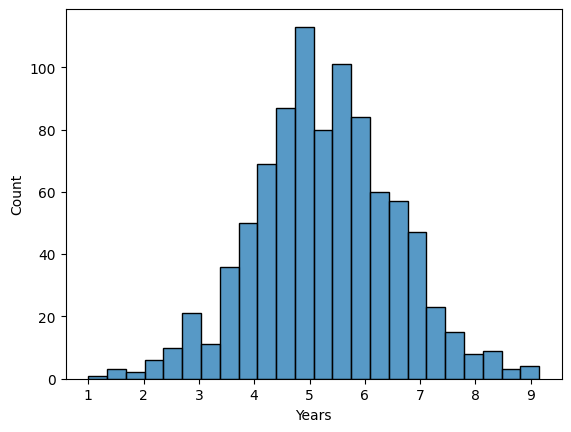

In [15]:
sns.histplot(df['Years'])

In [16]:
df['tenure_years'] = pd.cut(df['Years'], bins=[0,3,7,9], labels=['New',"mid",'old'])

<Axes: xlabel='tenure_years', ylabel='Count'>

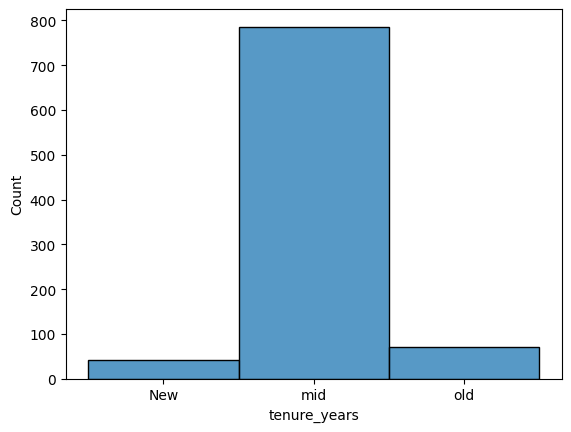

In [17]:
sns.histplot(df['tenure_years'] )

In [18]:
df.head()

,Names,Age,Total_Purchase,Account_Manager,Years,Num_Sites,Onboard_date,Location,Company,Churn,tenure_years
0,Cameron Williams,42.0,11066.80,0,7.22,8.0,2013-08-30 07:00:40,"10265 Elizabeth Mission Barkerburgh, AK 89518",Harvey LLC,1,old
1,Kevin Mueller,41.0,11916.22,0,6.50,11.0,2013-08-13 00:38:46,"6157 Frank Gardens Suite 019 Carloshaven, RI 1...",Wilson PLC,1,mid
2,Eric Lozano,38.0,12884.75,0,6.67,12.0,2016-06-29 06:20:07,"1331 Keith Court Alyssahaven, DE 90114","Miller, Johnson and Wallace",1,mid
3,Phillip White,42.0,8010.76,0,6.71,10.0,2014-04-22 12:43:12,"13120 Daniel Mount Angelabury, WY 30645-4695",Smith Inc,1,mid
4,Cynthia Norton,37.0,9191.58,0,5.56,9.0,2016-01-19 15:31:15,"765 Tricia Row Karenshire, MH 71730",Love-Jones,1,mid


In [19]:
df.groupby('Years')['Churn'].value_counts().sort_values(ascending=False).head(20)

Years  Churn
5.89   0        8
4.61   0        7
5.07   0        7
5.54   0        6
6.45   0        6
6.50   0        6
4.76   0        6
4.93   0        6
4.55   0        6
4.38   0        5
6.05   0        5
5.02   0        5
5.27   0        5
5.44   0        5
4.83   0        5
5.12   0        5
4.52   0        5
4.13   0        5
5.51   0        5
4.11   0        4
Name: count, dtype: int64

In [20]:
df.groupby('Num_Sites')['Churn'].value_counts().sort_values(ascending=False)

Num_Sites  Churn
8.0        0        205
9.0        0        167
7.0        0        144
10.0       0         97
6.0        0         66
11.0       1         46
           0         37
10.0       1         34
12.0       1         27
5.0        0         22
9.0        1         19
13.0       1          8
8.0        1          8
12.0       0          5
14.0       1          5
4.0        0          4
3.0        0          2
7.0        1          2
6.0        1          1
14.0       0          1
Name: count, dtype: int64

In [21]:
df['years_X_num_sites'] = df['Years'] * df['Num_Sites']

In [22]:
df.head(1)

,Names,Age,Total_Purchase,Account_Manager,Years,Num_Sites,Onboard_date,Location,Company,Churn,tenure_years,years_X_num_sites
0,Cameron Williams,42.0,11066.8,0,7.22,8.0,2013-08-30 07:00:40,"10265 Elizabeth Mission Barkerburgh, AK 89518",Harvey LLC,1,old,57.76


<Axes: xlabel='Total_Purchase', ylabel='Count'>

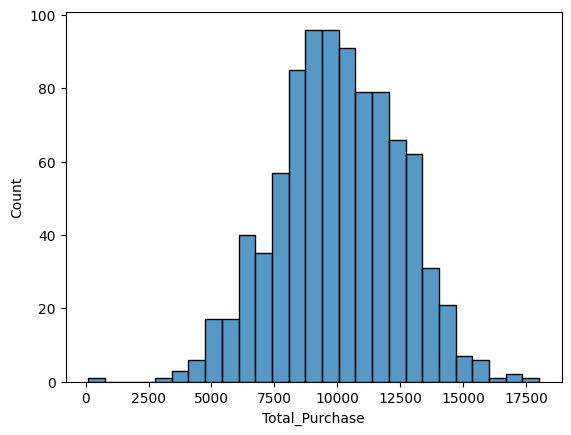

In [23]:
sns.histplot(df['Total_Purchase'])

In [24]:
df['log_total_purchase'] = np.log1p(df['Total_Purchase'])

In [25]:
df.head(3)

,Names,Age,Total_Purchase,Account_Manager,Years,Num_Sites,Onboard_date,Location,Company,Churn,tenure_years,years_X_num_sites,log_total_purchase
0,Cameron Williams,42.0,11066.80,0,7.22,8.0,2013-08-30 07:00:40,"10265 Elizabeth Mission Barkerburgh, AK 89518",Harvey LLC,1,old,57.76,9.311795
1,Kevin Mueller,41.0,11916.22,0,6.50,11.0,2013-08-13 00:38:46,"6157 Frank Gardens Suite 019 Carloshaven, RI 1...",Wilson PLC,1,mid,71.50,9.385740
2,Eric Lozano,38.0,12884.75,0,6.67,12.0,2016-06-29 06:20:07,"1331 Keith Court Alyssahaven, DE 90114","Miller, Johnson and Wallace",1,mid,80.04,9.463877


<Axes: xlabel='log_total_purchase', ylabel='Count'>

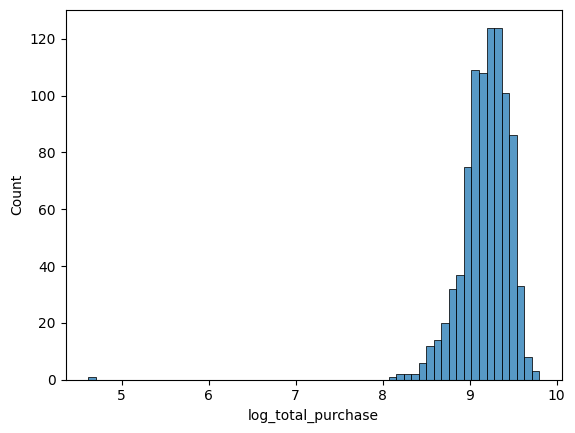

In [26]:
sns.histplot(df['log_total_purchase'])

In [27]:
df.describe()

,Age,Total_Purchase,Account_Manager,Years,Num_Sites,Onboard_date,Churn,years_X_num_sites,log_total_purchase
count,900.000000,900.000000,900.000000,900.000000,900.000000,900,900.000000,900.000000,900.000000
mean,41.816667,10062.824033,0.481111,5.273156,8.587778,2011-04-16 22:35:36.358888,0.166667,45.400711,9.181865
min,22.000000,100.000000,0.000000,1.000000,3.000000,2006-01-03 07:20:00,0.000000,10.000000,4.615121
25%,38.000000,8497.122500,0.000000,4.450000,7.000000,2008-06-29 16:05:08,0.000000,34.930000,9.047600
50%,42.000000,10045.870000,0.000000,5.215000,8.000000,2011-03-26 09:29:36.500000,0.000000,43.910000,9.215016
75%,46.000000,11760.105000,1.000000,6.110000,10.000000,2014-02-24 19:50:14.750000,0.000000,53.470000,9.372553
max,65.000000,18026.010000,1.000000,9.150000,14.000000,2016-12-28 04:07:38,1.000000,101.500000,9.799626
std,6.127560,2408.644532,0.499921,1.274449,1.764836,NaN,0.372885,15.084907,0.298455


In [28]:
df.sort_values(by='Total_Purchase', ascending=True)

,Names,Age,Total_Purchase,Account_Manager,Years,Num_Sites,Onboard_date,Location,Company,Churn,tenure_years,years_X_num_sites,log_total_purchase
659,Kayla Reeves,38.0,100.00,0,5.27,5.0,2006-03-10 09:01:48,"1511 Porter Drive Amberberg, NC 44608",Stewart-Lopez,0,mid,26.35,4.615121
371,Justin Campos,53.0,3263.00,1,2.77,9.0,2013-11-11 22:49:58,"3483 Davis Viaduct Guzmanmouth, RI 60858",Hall-Butler,0,New,24.93,8.090709
448,Lori Medina,39.0,3676.68,1,3.52,9.0,2008-07-16 11:36:45,"PSC 1874, Box 9238 APO AP 68299","Garcia, Hansen and Austin",0,mid,31.68,8.210037
229,Kelly Terry,45.0,3689.95,1,5.01,11.0,2014-09-10 10:05:06,"3798 Johnson Gardens Hughesside, PR 65467","Ellis, Johnston and Sullivan",0,mid,55.11,8.213639
777,Kathleen Marquez,35.0,3825.70,0,4.28,8.0,2006-05-15 18:02:51,"984 Gallagher Circle Port Gregorytown, MD 59029","Steele, Nguyen and Lewis",0,mid,34.24,8.249758
...,...,...,...,...,...,...,...,...,...,...,...,...,...
467,Holly Flores,47.0,15878.11,1,2.05,8.0,2012-05-21 12:56:15,"37362 Anthony Corner Suite 462 Port Saraton, N...",Reyes-Crawford,0,New,16.40,9.672760
818,Eric Terry,42.0,16371.42,1,3.84,10.0,2014-12-18 16:51:16,2384 Lucero Trafficway Suite 201 Campbellchest...,White-Thomas,0,mid,38.40,9.703353
41,Jason Jones MD,55.0,16838.94,1,6.66,8.0,2007-05-10 15:48:38,"52454 Jessica Passage Apt. 097 Mitchellburgh, ...",Brown-Richardson,1,mid,53.28,9.731509
770,Kevin Powell,43.0,16955.76,0,7.04,8.0,2007-11-14 07:55:14,"33165 Joshua Streets Suite 299 Josephchester, ...",Carroll Ltd,0,old,56.32,9.738422


In [29]:
df = df.drop(659)

In [30]:
df.sort_values(by='Total_Purchase', ascending=True)

,Names,Age,Total_Purchase,Account_Manager,Years,Num_Sites,Onboard_date,Location,Company,Churn,tenure_years,years_X_num_sites,log_total_purchase
371,Justin Campos,53.0,3263.00,1,2.77,9.0,2013-11-11 22:49:58,"3483 Davis Viaduct Guzmanmouth, RI 60858",Hall-Butler,0,New,24.93,8.090709
448,Lori Medina,39.0,3676.68,1,3.52,9.0,2008-07-16 11:36:45,"PSC 1874, Box 9238 APO AP 68299","Garcia, Hansen and Austin",0,mid,31.68,8.210037
229,Kelly Terry,45.0,3689.95,1,5.01,11.0,2014-09-10 10:05:06,"3798 Johnson Gardens Hughesside, PR 65467","Ellis, Johnston and Sullivan",0,mid,55.11,8.213639
777,Kathleen Marquez,35.0,3825.70,0,4.28,8.0,2006-05-15 18:02:51,"984 Gallagher Circle Port Gregorytown, MD 59029","Steele, Nguyen and Lewis",0,mid,34.24,8.249758
649,Cheryl Hernandez,46.0,4111.40,0,3.93,8.0,2010-02-18 18:40:00,"7772 Elizabeth Ridge North Chloe, AL 79941",Beltran Group,0,mid,31.44,8.321762
...,...,...,...,...,...,...,...,...,...,...,...,...,...
467,Holly Flores,47.0,15878.11,1,2.05,8.0,2012-05-21 12:56:15,"37362 Anthony Corner Suite 462 Port Saraton, N...",Reyes-Crawford,0,New,16.40,9.672760
818,Eric Terry,42.0,16371.42,1,3.84,10.0,2014-12-18 16:51:16,2384 Lucero Trafficway Suite 201 Campbellchest...,White-Thomas,0,mid,38.40,9.703353
41,Jason Jones MD,55.0,16838.94,1,6.66,8.0,2007-05-10 15:48:38,"52454 Jessica Passage Apt. 097 Mitchellburgh, ...",Brown-Richardson,1,mid,53.28,9.731509
770,Kevin Powell,43.0,16955.76,0,7.04,8.0,2007-11-14 07:55:14,"33165 Joshua Streets Suite 299 Josephchester, ...",Carroll Ltd,0,old,56.32,9.738422


<Axes: xlabel='log_total_purchase', ylabel='Count'>

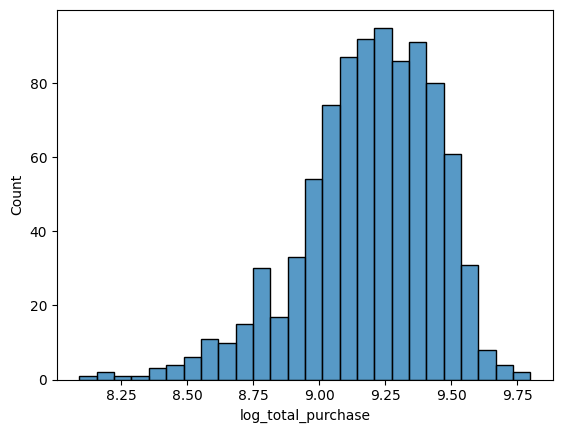

In [31]:
sns.histplot(df['log_total_purchase'])

In [32]:
df.head(1)

,Names,Age,Total_Purchase,Account_Manager,Years,Num_Sites,Onboard_date,Location,Company,Churn,tenure_years,years_X_num_sites,log_total_purchase
0,Cameron Williams,42.0,11066.8,0,7.22,8.0,2013-08-30 07:00:40,"10265 Elizabeth Mission Barkerburgh, AK 89518",Harvey LLC,1,old,57.76,9.311795


In [33]:
X = df.drop('Churn', axis=1)

y = df['Churn']

In [34]:
X.columns

Index(['Names', 'Age', 'Total_Purchase', 'Account_Manager', 'Years',
       'Num_Sites', 'Onboard_date', 'Location', 'Company', 'tenure_years',
       'years_X_num_sites', 'log_total_purchase'],
      dtype='str')

In [35]:
from sklearn.model_selection import train_test_split

In [36]:
X_train,X_test, y_train,y_test = train_test_split(
    X,y, test_size=.20,random_state=42
)



In [37]:
print('Shape of X_train: ', X_train.shape)
print('Shape of y_train: ', y_train.shape)
print('Shape of X_test: ', X_test.shape)
print('Shape of X_test: ', y_test.shape)

Shape of X_train:  (719, 12)
Shape of y_train:  (719,)
Shape of X_test:  (180, 12)
Shape of X_test:  (180,)


MODEL ENGINEERING

In [38]:
X.info()

<class 'pandas.DataFrame'>
Index: 899 entries, 0 to 899
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Names               899 non-null    str           
 1   Age                 899 non-null    float64       
 2   Total_Purchase      899 non-null    float64       
 3   Account_Manager     899 non-null    int64         
 4   Years               899 non-null    float64       
 5   Num_Sites           899 non-null    float64       
 6   Onboard_date        899 non-null    datetime64[us]
 7   Location            899 non-null    str           
 8   Company             899 non-null    str           
 9   tenure_years        898 non-null    category      
 10  years_X_num_sites   899 non-null    float64       
 11  log_total_purchase  899 non-null    float64       
dtypes: category(1), datetime64[us](1), float64(6), int64(1), str(3)
memory usage: 85.2 KB


In [39]:
numeric_feature=X.select_dtypes(
    include=['float64', 'int64']
).columns

categorical_features = [
    'Account_Manager',
    'tenure_years'
]

In [40]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder

In [41]:
prepro = ColumnTransformer(
    transformers=(
        ('num', StandardScaler(),numeric_feature),
        ('cat',OneHotEncoder(drop='if_binary'),categorical_features)
    )
)

In [42]:
from sklearn.linear_model import LogisticRegression

In [43]:
log_reg_pp = Pipeline([
    ('preprocessor',prepro),
    ('model', LogisticRegression())
])

In [44]:
log_reg_pp.fit(X_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","(('num', ...), ...)"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sp

In [45]:
pred_Log_reg = log_reg_pp.predict(X_test)

In [46]:
pred_Log_reg

array([0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0,
       0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0,
       0, 0, 0, 0])

In [47]:
y_test

332    0
812    0
745    0
244    0
39     1
      ..
779    0
25     1
84     1
10     1
333    0
Name: Churn, Length: 180, dtype: int64

In [48]:
from sklearn.metrics import confusion_matrix, classification_report

In [49]:
print('confusion_matrix: \n' , confusion_matrix(y_test, pred_Log_reg))
print('classification_report: \n', classification_report(y_test, pred_Log_reg))

confusion_matrix: 
 [[141   7]
 [ 14  18]]
classification_report: 
               precision    recall  f1-score   support

           0       0.91      0.95      0.93       148
           1       0.72      0.56      0.63        32

    accuracy                           0.88       180
   macro avg       0.81      0.76      0.78       180
weighted avg       0.88      0.88      0.88       180



In [50]:
results = X_test.copy()

results['Actual'] = y_test

results['predicted'] = pred_Log_reg 

results.head(2)

,Names,Age,Total_Purchase,Account_Manager,Years,Num_Sites,Onboard_date,Location,Company,tenure_years,years_X_num_sites,log_total_purchase,Actual,predicted
332,Nicole Jacobson,41.0,8783.13,1,6.20,7.0,2009-08-10 16:00:31,"029 Bill Alley Apt. 087 West Kenneth, UT 32896","Hoffman, Leach and Smith",mid,43.40,9.080702,0,0
812,Kenneth Wilkerson,42.0,11670.32,0,5.51,7.0,2014-08-05 21:37:57,Unit 8005 Box 5636 DPO AA 90315-7695,"Aguilar, Kelly and Fuentes",mid,38.57,9.364890,0,0


In [51]:
wrong_pred = results[results['Actual'] != results['predicted']]

Correct_pred = results[results['Actual'] == results['predicted']]

In [52]:
wrong_pred.describe()

,Age,Total_Purchase,Account_Manager,Years,Num_Sites,Onboard_date,years_X_num_sites,log_total_purchase,Actual,predicted
count,21.000000,21.000000,21.000000,21.000000,21.000000,21,21.000000,21.000000,21.000000,21.000000
mean,43.476190,10421.587619,0.571429,6.060476,9.523810,2011-06-02 10:00:31.714285,57.705714,9.227246,0.666667,0.333333
min,29.000000,6351.790000,0.000000,4.260000,6.000000,2006-04-03 00:11:53,35.160000,8.756649,0.000000,0.000000
25%,40.000000,8688.170000,0.000000,5.160000,9.000000,2008-07-26 03:00:31,46.500000,9.069833,0.000000,0.000000
50%,45.000000,10793.110000,1.000000,5.720000,10.000000,2011-09-27 06:52:13,54.600000,9.286756,1.000000,0.000000
75%,48.000000,12112.530000,1.000000,6.940000,10.000000,2014-07-31 01:07:38,68.900000,9.402078,1.000000,1.000000
max,54.000000,13731.450000,1.000000,8.360000,12.000000,2016-12-28 04:07:38,81.500000,9.527517,1.000000,1.000000
std,6.667976,2250.256161,0.507093,1.199293,1.364516,NaN,13.992306,0.232957,0.483046,0.483046


In [53]:
Correct_pred.describe()

,Age,Total_Purchase,Account_Manager,Years,Num_Sites,Onboard_date,years_X_num_sites,log_total_purchase,Actual,predicted
count,159.000000,159.000000,159.000000,159.000000,159.000000,159,159.000000,159.000000,159.000000,159.000000
mean,42.572327,10120.548742,0.465409,5.141321,8.270440,2011-03-04 02:23:30.496855,42.580126,9.190722,0.113208,0.113208
min,22.000000,4316.730000,0.000000,1.660000,3.000000,2006-01-03 20:57:16,11.620000,8.370485,0.000000,0.000000
25%,38.000000,8675.195000,0.000000,4.440000,7.000000,2008-07-11 13:28:34.500000,32.550000,9.068337,0.000000,0.000000
50%,43.000000,10133.360000,0.000000,5.040000,8.000000,2011-04-06 23:57:31,41.040000,9.223687,0.000000,0.000000
75%,47.000000,11726.865000,1.000000,5.965000,9.000000,2013-08-28 14:30:40,50.060000,9.369719,0.000000,0.000000
max,58.000000,16371.420000,1.000000,8.970000,13.000000,2016-12-02 22:38:03,89.700000,9.703353,1.000000,1.000000
std,6.400612,2426.819450,0.500378,1.279475,1.752703,NaN,14.657285,0.261480,0.317847,0.317847


In [54]:
probabilities = log_reg_pp.predict_proba(X_test)

In [55]:
probadf = pd.DataFrame(
    probabilities,
    columns=['Stay_proba', 'churn_proba']
)

probadf.head(5)

,Stay_proba,churn_proba
0,0.985690,0.014310
1,0.992368,0.007632
2,0.997041,0.002959
3,0.996229,0.003771
4,0.367839,0.632161


In [56]:
churn_proba = probabilities[:,1]

In [57]:
threshold = .7
pred_proba = (churn_proba >= threshold).astype(int)

print('threshold Value: ',  threshold)
print('confusion_matrix: \n' , confusion_matrix(y_test, pred_proba))
print('classification_report: \n', classification_report(y_test, pred_proba))

threshold Value:  0.7
confusion_matrix: 
 [[147   1]
 [ 22  10]]
classification_report: 
               precision    recall  f1-score   support

           0       0.87      0.99      0.93       148
           1       0.91      0.31      0.47        32

    accuracy                           0.87       180
   macro avg       0.89      0.65      0.70       180
weighted avg       0.88      0.87      0.85       180



In [58]:
print('confusion_matrix: \n' , confusion_matrix(y_test, pred_Log_reg))
print('classification_report: \n', classification_report(y_test, pred_Log_reg))

confusion_matrix: 
 [[141   7]
 [ 14  18]]
classification_report: 
               precision    recall  f1-score   support

           0       0.91      0.95      0.93       148
           1       0.72      0.56      0.63        32

    accuracy                           0.88       180
   macro avg       0.81      0.76      0.78       180
weighted avg       0.88      0.88      0.88       180



In [61]:
log_reg_steps = log_reg_pp.named_steps['model']

In [63]:
feature_names = log_reg_pp.named_steps['preprocessor'].get_feature_names_out()

In [66]:
coef_df = pd.DataFrame({
    'Featurename' : feature_names,
    'Coefficient': log_reg_steps.coef_[0]
})

In [68]:
top10 = coef_df.head(10).sort_values(by= 'Coefficient', ascending= False)

In [69]:
top10

,Featurename,Coefficient
4,num__Num_Sites,1.610579
5,num__years_X_num_sites,0.888926
8,cat__tenure_years_New,0.882477
0,num__Age,0.321983
2,num__Account_Manager,0.189112
1,num__Total_Purchase,0.134917
3,num__Years,0.122560
7,cat__Account_Manager_1,0.091551
6,num__log_total_purchase,-0.026513
9,cat__tenure_years_mid,-0.107714
